Student Performance Prediction System

Name: Sinchana

In [ ]:
import pandas as pd # for handling data
import numpy as np # for numerical operations
import matplotlib.pyplot as plt # for visualization

In [ ]:
data = {
    'Student_ID': [1,2,3,4,5,6,7,8,9,10],
    'Study_Hours': [2,4,6,1,5,7,3,6,4,5],
    'Attendance': [65,75,92,50,85,96,70,88,78,82],
    'Previous_Marks': [55,60,85,40,75,90,65,80,72,77],
    'Assignments': [50,60,88,45,78,92,68,85,74,79],
    'Internal_Marks': [52,62,86,42,76,91,66,82,73,78],
    'Result': ['Fail','Pass','Pass','Fail','Pass','Pass','Fail','Pass','Pass','Pass']
}



In [ ]:
student_data = pd.DataFrame(data)


In [ ]:
# display dataset
student_data.head()

,Student_ID,Study_Hours,Attendance,Previous_Marks,Assignments,Internal_Marks,Result
0,1,2,65,55,50,52,Fail
1,2,4,75,60,60,62,Pass
2,3,6,92,85,88,86,Pass
3,4,1,50,40,45,42,Fail
4,5,5,85,75,78,76,Pass


In [ ]:
student_data.to_csv("student_dataset.csv", index=False) # saving dataset as CSV file

In [ ]:
from sklearn.preprocessing import LabelEncoder

#converting Pass/Fail into numeric values
encoder = LabelEncoder()
student_data['Result'] = encoder.fit_transform(student_data['Result'])

In [ ]:
X = student_data[['Study_Hours', 'Attendance', 'Previous_Marks', 'Assignments', 'Internal_Marks']] #Selecting input and output
y = student_data['Result']

In [ ]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2) #spliting dataset into training and testing

In [ ]:
# This model helps to predict student result based on performance
from sklearn.ensemble import RandomForestClassifier
#creating model
model = RandomForestClassifier()
#training model
model.fit(X_train, y_train)



RandomForestClassifier()

In [ ]:
# checking feature importance
for i, col in enumerate(X.columns):
  print(col, ":", model.feature_importances_[i])

Study_Hours : 0.14285714285714285
Attendance : 0.1836734693877551
Previous_Marks : 0.1836734693877551
Assignments : 0.22448979591836735
Internal_Marks : 0.2653061224489796


In [ ]:
y_pred = model.predict(X_test) #predicting test data

In [ ]:
from sklearn.metrics import accuracy_score
#evaluating model
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.5


In [ ]:
# testing with new student data
new_student = pd.DataFrame([[5, 85, 78, 80, 79]],
columns=['Study_Hours', 'Attendance', 'Previous_Marks', 'Assignments', 'Internal_Marks'])

In [ ]:
result = model.predict(new_student)

In [ ]:
if result[0] == 1:
    print("PASS")
else:
    print("FAIL")

PASS


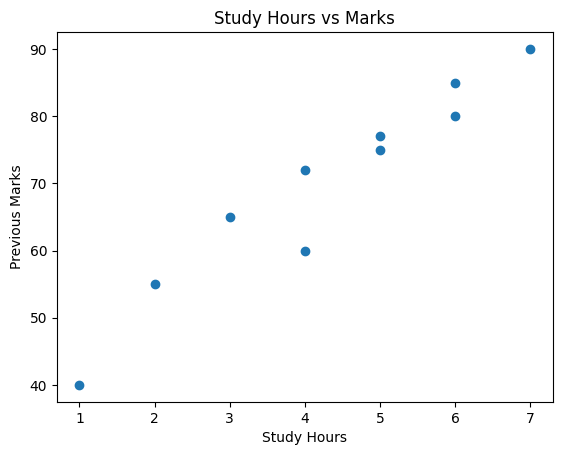

In [ ]:
# graph between study hours and marks

plt.scatter(student_data['Study_Hours'], student_data['Previous_Marks'])
plt.xlabel("Study Hours")
plt.ylabel("Previous Marks")
plt.title("Study Hours vs Marks")
plt.show()

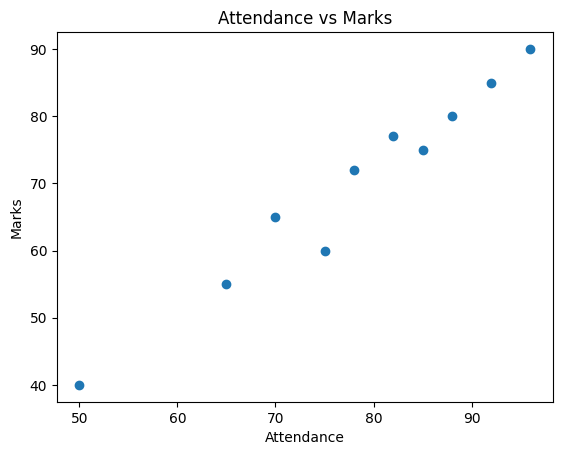

In [ ]:
plt.scatter(student_data['Attendance'], student_data['Previous_Marks'])
plt.xlabel("Attendance")
plt.ylabel("Marks")
plt.title("Attendance vs Marks")
plt.show()